In [1]:
import torch, torchvision
import torch.nn as nn
import torch.backends.cudnn as cudnn

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

import umap

import json, re
from tqdm.notebook import tqdm

from shared import *

cudnn.benchmark = True
plt.ion();

# 0. Utils

In [2]:
DEVICE = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
BATCH_SIZE = 64
LR=0.001
MOMENTUM=0.9
STEP_SIZE = 7
GAMMA = 0.1
N_EPOCHS = 5
print(f"Using {DEVICE=}")

Using DEVICE='cpu'


# 1. Baseline Setup

In [3]:
def process_fn(inp):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    return inp

def visualize(inputs, classes, dataloader):
    
    plt.figure(figsize=(10,4))
    sns.set_theme(style='white', palette='deep')
    
    n_cols = 5
    n_rows = int(np.ceil(inputs.shape[0] / n_cols))
    
    for i, (im, label) in enumerate(zip(inputs, classes), start=1):
        class_name = dataloader.dataset.classes[label].title()
        plt.subplot(n_rows, n_cols, i)
        imshow(im, process_fn, class_name)
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.show()

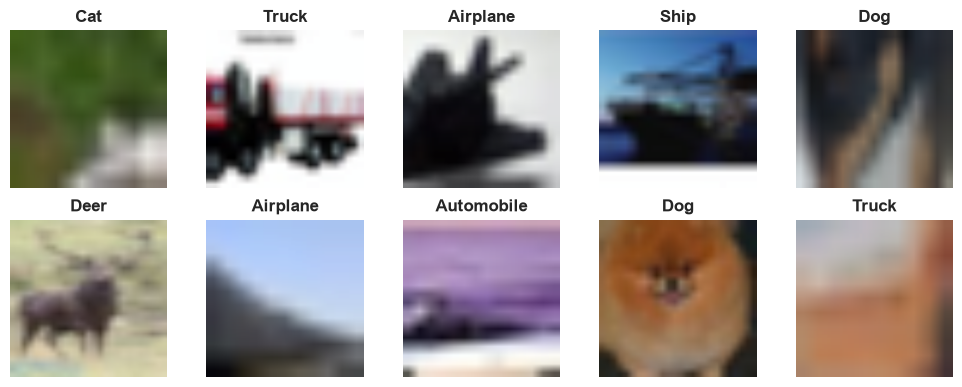

In [4]:
dataloaders, dataset_sizes = load_cifar(batch_size=BATCH_SIZE)
data_iter = iter(dataloaders["train"])
xb, yb = next(data_iter)

N=10
visualize(xb[:N], yb[:N], dataloaders["train"])

In [5]:
def load_model(pretrained=True):
    weights = torchvision.models.ResNet152_Weights.IMAGENET1K_V1 if pretrained else None
    return torchvision.models.resnet152(weights=weights)

def add_clf_head(resnet):
    n_features = resnet.fc.in_features
    resnet.fc = nn.Linear(n_features, 10, bias=True)
    return resnet

In [6]:
model_baseline = add_clf_head(freeze_model(load_model())).to(DEVICE)
criterion, optimizer, exp_sched = create_classification(model_baseline.fc, lr=LR, momentum=MOMENTUM, step_size=STEP_SIZE, gamma=GAMMA)

In [7]:
tracker_baseline = GradientTracker(model_baseline)  # for comparison in Part 2

In [ ]:
train_model("cnn-task_baseline", model_baseline, criterion, optimizer, exp_sched, dataloaders, dataset_sizes, num_epochs=N_EPOCHS)

In [8]:
tracker_baseline.unregister()

  0%|          | 0/3 [00:00<?, ?it/s]

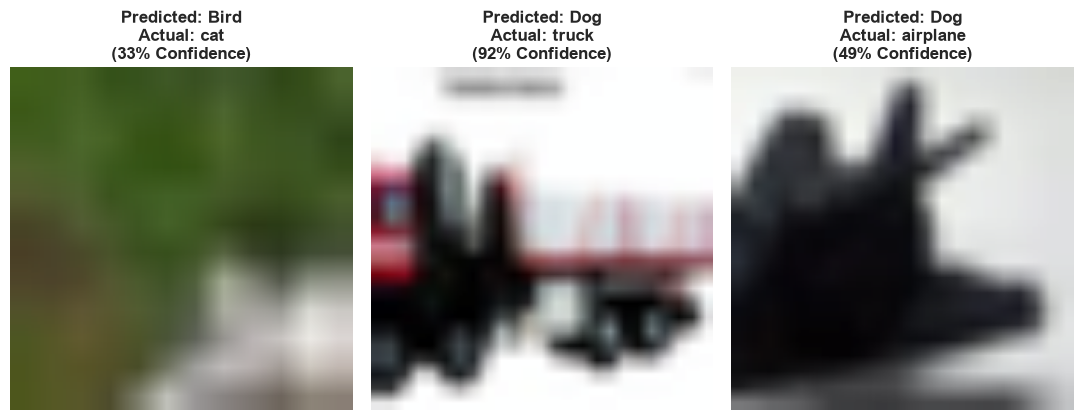

In [14]:
def run_inference(model, image):
    image = image[None].to(DEVICE)
    outputs = model(image)
    confidence, predicted_label = torch.max(outputs, 1)
    return image[0], predicted_label, confidence

class_names = dataloaders["train"].dataset.classes
visualize_model(model_baseline, process_fn, [(xb[i], class_names[yb[i]]) for i in range(3)], class_names, run_inference)

In [ ]:
del model_baseline
del criterion
del optimizer
del exp_sched

free_mem()

# 2. Residual Connections in Practice

In [ ]:
def remove_skip_connections(model):
    def _overriden_forward(self, x):
        out = x
        
        out = self.conv1(out)
        out = self.bn1(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        out = self.conv3(out)
        out = self.bn3(out)

        out = self.relu(out)
        
        return out
    
    for module in model.modules():
        if isinstance(module, torchvision.models.resnet.Bottleneck):
            module.forward = _overriden_forward.__get__(module, torchvision.models.resnet.Bottleneck)
    
    return model

In [ ]:
model_no_skip = remove_skip_connections(add_clf_head(freeze_model(load_model()))).to(DEVICE)
criterion, optimizer, exp_sched = create_classification(model_no_skip.fc, lr=LR, momentum=MOMENTUM, step_size=STEP_SIZE, gamma=GAMMA)

In [ ]:
model_no_skip.layer1

In [ ]:
tracker_no_skip = GradientTracker(model_no_skip)  # for comparison with baseline

In [ ]:
train_model("cnn-task_no-skip", model_no_skip, criterion, optimizer, exp_sched, dataloaders, dataset_sizes, num_epochs=1)

In [ ]:
tracker_no_skip.unregister()

In [ ]:
baseline_weight_grad_df = pd.DataFrame(tracker_baseline.gradients["fc.weight"])
no_skip_weight_grad_df = pd.DataFrame(tracker_no_skip.gradients["fc.weight"])

In [ ]:
f, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(15,3))
sns.set_theme(style="whitegrid")

for (perf_df, label) in [
    (baseline_weight_grad_df, "baseline"),
    (no_skip_weight_grad_df, "no-skip"),
]:
    lineplot_kwargs = dict(markersize=0, linewidth=3, label=label)
    configs = [
        {
            "column": "norm",
            "title": "Gradient Norm",
            "xlabel": "Iterations",
            "ylabel": "",
            "lineplot_kwargs": {**lineplot_kwargs, "ax": ax1},
        },
        {
            "column": "mean",
            "title": "Gradient Mean",
            "xlabel": "Iterations",
            "ylabel": "",
            "lineplot_kwargs": {**lineplot_kwargs, "ax": ax2},
        },
        {
            "column": "std",
            "title": "Gradient Standard Deviation",
            "xlabel": "Iterations",
            "ylabel": "",
            "lineplot_kwargs": {**lineplot_kwargs, "ax": ax3},
        },
    ]
    
    plot_line(perf_df, configs)

plt.show()

In [ ]:
del model_no_skip
del criterion
del optimizer
del exp_sched

free_mem()

# 3. Feature Hierarchies and Representations

In [ ]:
class FeatureTracker:
    def __init__(self, model):
        self.layer_name_pattern = r'^layer[0-9]\.[0-9]$'  # e.g. layer1.1, layer2.0, etc
        self.features = {name: [] for name, _ in model.named_modules() if re.search(self.layer_name_pattern, name)}
        self.labels = []
        self.handles = []
        self._register_hooks(model)
        
    def _register_hooks(self, model):
        for name, module in model.named_modules():
            if re.search(self.layer_name_pattern, name):
                def hook_fn(module, args, output, name=name):
                    if name in self.features:
                        self.features[name].append(output)
                handle = module.register_forward_hook(hook_fn)
                self.handles.append(handle)
    
    def unregister(self):
        for handle in self.handles:
            handle.remove()

In [ ]:
def track_val_features(model, num_batches=6):
    was_training = model.training
    tracker_features = FeatureTracker(model_vis)
    model.eval()
    
    with torch.no_grad(), tqdm(total=num_batches) as pbar:
        for i, (inputs, labels) in enumerate(dataloaders['val'], start=1):
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)

            _ = model(inputs)
            tracker_features.labels.append(labels)

            pbar.update(1)
                
            if i == num_batches:
                model.train(mode=was_training)
                break
        
    model.train(mode=was_training)
    tracker_features.unregister()
    
    return tracker_features.features, tracker_features.labels

def visualize_features(features, labels, class_names, title):
    features = torch.concat(features)
    labels = torch.concat(labels)
    features = features.reshape((features.shape[0], -1))
    
    label_names = [class_names[x.numpy().tolist()] for x in labels]
    
    reducer = umap.UMAP()
    embedding = reducer.fit_transform(features)
    
    sns.set_theme(style="white", palette="muted")
    plt.figure(figsize=(6, 4))
    sns.scatterplot(
        data=pd.DataFrame({
            "umap_1": embedding[:,0],
            "umap_2": embedding[:,1],
            "label": label_names,
            }),
        x='umap_1',
        y='umap_2',
        hue='label',
        palette='tab10',
        s=30,
        alpha=0.8,
        edgecolor='none'
    )

    plt.title(title, fontsize=14)
    plt.xlabel('UMAP Dimension 1')
    plt.ylabel('UMAP Dimension 2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
    plt.gca().set_aspect('equal', 'datalim')
    sns.despine()
    plt.tight_layout()
    plt.show()

In [ ]:
model_vis = load_model()

In [ ]:
features, labels = track_val_features(model_vis, num_batches=50)

In [ ]:
for layer_suffix, placement in zip(["1.0", "2.7", "4.2"], ["early", "middle", "late"]):
    subset = features[f"layer{layer_suffix}"]
    visualize_features(subset, labels, dataloaders["val"].dataset.classes, f"UMAP Projection for {placement.title()} Features")

In [ ]:
del model_vis
del features
del labels

free_mem()

# 4. Transfer Learning and Generalization

## Random Weights, Full Finetuning

In [ ]:
model = add_clf_head(load_model(pretrained=False)).to(DEVICE)
criterion, optimizer, exp_sched = create_classification(model,
                                                        lr=LR, momentum=MOMENTUM, step_size=STEP_SIZE, gamma=GAMMA,
                                                        head_only=False)

In [ ]:
train_model("cnn-task_random-full", model, criterion, optimizer, exp_sched, dataloaders, dataset_sizes, num_epochs=N_EPOCHS)

In [ ]:
del model
del criterion
del optimizer
del exp_sched

free_mem()

## Pretrained Weights, Full Finetuning

In [ ]:
model = add_clf_head(load_model(pretrained=True)).to(DEVICE)
criterion, optimizer, exp_sched = create_classification(model,
                                                        lr=LR, momentum=MOMENTUM, step_size=STEP_SIZE, gamma=GAMMA,
                                                        head_only=False)

In [ ]:
train_model("cnn-task_pretrained-full", model, criterion, optimizer, exp_sched, dataloaders, dataset_sizes, num_epochs=N_EPOCHS)

In [ ]:
del model
del criterion
del optimizer
del exp_sched

free_mem()

## Random Weights, Final Block Finetuning

In [ ]:
model = add_clf_head(freeze_model(load_model(pretrained=False))).to(DEVICE)
criterion, optimizer, exp_sched = create_classification(model.fc,
                                                        lr=LR, momentum=MOMENTUM, step_size=STEP_SIZE, gamma=GAMMA,
                                                        head_only=True)

In [ ]:
train_model("cnn-task_random-final-block", model, criterion, optimizer, exp_sched, dataloaders, dataset_sizes, num_epochs=N_EPOCHS)

In [ ]:
del model
del criterion
del optimizer
del exp_sched

free_mem()

## Pretrained Weights, Final Block Finetuning

In [ ]:
model = add_clf_head(freeze_model(load_model(pretrained=True))).to(DEVICE)
criterion, optimizer, exp_sched = create_classification(model.fc,
                                                        lr=LR, momentum=MOMENTUM, step_size=STEP_SIZE, gamma=GAMMA,
                                                        head_only=True)

In [ ]:
train_model("cnn-task_pretrained-final-block", model, criterion, optimizer, exp_sched, dataloaders, dataset_sizes, num_epochs=N_EPOCHS)

In [ ]:
del model
del criterion
del optimizer
del exp_sched

free_mem()

In [ ]:
f, (ax1, ax2) = plt.subplots(1,2, figsize=(10,3))

for fname in ["cnn-task_baseline", "cnn-task_no-skip"]:
    with open(f"{fname}.json", "r") as f:
        perf = json.loads(f.read())

    perf_df = pd.DataFrame(perf)
    label = fname.split("_")[-1]
    lineplot_kwargs = dict(markersize=6, linewidth=3, label=label)
    
    configs = [
        {
            "column": "loss",
            "title": "Cross-Entropy Loss",
            "xlabel": "Epochs",
            "ylabel": "",
            "lineplot_kwargs": {**lineplot_kwargs, "ax": ax1},
        },
        {
            "column": "accuracy",
            "title": "Accuracy",
            "xlabel": "Epochs",
            "ylabel": "",
            "ylim": (0,1),
            "lineplot_kwargs": {**lineplot_kwargs, "ax": ax2},
        },
    ]
    
    plot_line(perf_df, configs)

plt.show()